In [1]:
import pandas as pd
import numpy as np
import math
import shap

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix


# Caso de Prevenção a Fraudes em Transações com Cartão de Crédito

## Contexto

A empresa está enfrentando um aumento significativo de transações fraudulentas com cartões de crédito, o que prejudica a confiança dos clientes e causa perdas financeiras. Sua tarefa é desenvolver um modelo preditivo que possa identificar transações fraudulentas com alta precisão, minimizando assim o impacto financeiro e protegendo a reputação da instituição.

## Conjunto de dados:

### Dicionário de dados

Descrição das colunas do conjunto de dados utilizadas para detecção de fraudes em transações.

#### Variáveis do Conjunto de Dados

| Variável                       | Tipo          | Descrição                                                                 |
|--------------------------------|---------------|---------------------------------------------------------------------------|
| **distance_from_home**         | float         | Distância (em unidades arbitrárias) entre o local da compra e a residência do cliente. |
| **distance_from_last_transaction** | float     | Distância entre a transação atual e a última transação registrada do mesmo cliente. |
| **ratio_to_median_purchase_price** | float     | Razão entre o valor da compra atual e o valor mediano das compras anteriores do cliente. |
| **repeat_retailer**            | float (0 ou 1) | Indica se a transação foi realizada em um varejista já utilizado anteriormente pelo cliente. |
| **used_chip**                  | float (0 ou 1) | Indica se a transação foi realizada utilizando o chip do cartão. |
| **used_pin_number**            | float (0 ou 1) | Indica se a transação exigiu a digitação da senha (PIN) do cliente. |
| **online_order**               | float (0 ou 1) | Indica se a transação foi realizada online (1) ou presencialmente (0). |
| **fraud**                      | float (0 ou 1) | Variável alvo: identifica se a transação foi fraudulenta (1) ou legítima (0). |

---

## Objetivo

O objetivo deste projeto é desenvolver, avaliar e validar modelos de aprendizado de máquina capazes de detectar transações fraudulentas de cartão de crédito com **alta precisão e recall**.  

O trabalho envolve:  
- Pré-processamento dos dados (engenharia de atributos, normalização e tratamento de desbalanceamento de classes).  
- Treinamento de modelos de classificação com **Gradient Boosting (XGBoost)**.  
- Avaliação com métricas: **ROC-AUC, precisão, recall, F1-score** e **matriz de confusão**.  

O objetivo final é criar uma solução **robusta e escalável**, aplicável em sistemas financeiros reais, reduzindo perdas econômicas e aumentando a confiança dos clientes.

---

## CRISP-DM

Pipeline baseada no framework **CRISP-DM**:

1. **Definir o problema de negócio.**  
2. **Coletar os dados e obter uma visão geral.**  
3. **Dividir os dados em treino e teste.**  
4. **Explorar os dados (EDA).**  
5. **Engenharia de atributos, limpeza e pré-processamento.**  
6. **Treinamento, comparação, seleção de variáveis e ajuste de hiperparâmetros.**  
7. **Teste e avaliação do modelo final.**  
8. **Conclusão e interpretação dos resultados.**  
9. **Implantação (deploy).**

---

## Análise Exploratória de Dados (EDA)

### 1. Visão Geral do Conjunto de Dados
- Total de registros: **1.000.000 transações**  
- Variável alvo: **fraud** (0 = legítima, 1 = fraudulenta)  
- Variáveis analisadas:  
  - **Numéricas:** distance_from_home, distance_from_last_transaction, ratio_to_median_purchase_price  
  - **Binárias/Categóricas:** repeat_retailer, used_chip, used_pin_number, online_order  

---

### 2. Verificação da Qualidade dos Dados
- Nenhum valor ausente.  
- Outliers identificados:  
  - distance_from_home → 10,36%  
  - ratio_to_median_purchase_price → 8,44%  
  - repeat_retailer → 11,86%  
  - distance_from_last_transaction → 12,43%  
  - used_pin_number → 10,07%  
- Variáveis **used_chip** e **online_order** → sem outliers.  

---

### 3. Distribuição das Variáveis Numéricas
- **distance_from_home:** assimetria à direita, valores concentrados próximos a zero, alguns casos extremos.  
- **distance_from_last_transaction:** padrão semelhante, com cauda longa.  
- **ratio_to_median_purchase_price:** maioria próxima de 1, mas outliers com valores anormais.  

---

### 4. Distribuição das Variáveis Binárias
- **repeat_retailer:** ~12% anomalias (uso incomum de varejistas).  
- **used_chip:** distribuição equilibrada.  
- **used_pin_number:** ~10% anomalias (uso irregular do PIN).  
- **online_order:** distribuição equilibrada (0 = presencial, 1 = online).  

---

### 5. Fraudes vs. Transações Legítimas
- Fraudes são **raras** (dataset altamente desbalanceado).  
- Visualizações iniciais:  
  - Gráfico de dispersão (`distance_from_home` vs `distance_from_last_transaction`) mostra agrupamentos de fraudes.  
  - Anomalias de preço (`ratio_to_median_purchase_price`) + distância → fortes sinais de fraude.  

---

### 6. Principais Insights para Modelagem
- **Preditores fortes:** distance_from_home, distance_from_last_transaction, ratio_to_median_purchase_price.  
- **Variáveis binárias (used_pin_number, online_order):** bons separadores entre fraude e legítimo.  
- **Necessário tratamento do desbalanceamento (ex.: SMOTE).**  
---


In [3]:
df = pd.read_csv('./fraud_dataset.csv')

df

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
999995,2.207101,0.112651,1.626798,1.0,1.0,0.0,0.0,0.0
999996,19.872726,2.683904,2.778303,1.0,1.0,0.0,0.0,0.0
999997,2.914857,1.472687,0.218075,1.0,1.0,0.0,1.0,0.0
999998,4.258729,0.242023,0.475822,1.0,0.0,0.0,1.0,0.0


In [4]:
df.isnull().sum()
print(df.isnull().sum()) # se há dados nulos

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64


In [5]:
linhas, colunas = df.shape[0], df.shape[1] # quantidade de linhas e colunas
print(f'\nTemos {linhas} linhas e {colunas} colunas.')


Temos 1000000 linhas e 8 colunas.


In [6]:
# Informações das colunas

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_from_home,1000000.0,26.628792,65.390784,0.004874,3.878008,9.967760,25.743985,10632.723672
distance_from_last_transaction,1000000.0,5.036519,25.843093,0.000118,0.296671,0.998650,3.355748,11851.104565
ratio_to_median_purchase_price,1000000.0,1.824182,2.799589,0.004399,0.475673,0.997717,2.096370,267.802942
repeat_retailer,1000000.0,0.881536,0.323157,0.000000,1.000000,1.000000,1.000000,1.000000
used_chip,1000000.0,0.350399,0.477095,0.000000,0.000000,0.000000,1.000000,1.000000
used_pin_number,1000000.0,0.100608,0.300809,0.000000,0.000000,0.000000,0.000000,1.000000
online_order,1000000.0,0.650552,0.476796,0.000000,0.000000,1.000000,1.000000,1.000000
fraud,1000000.0,0.087403,0.282425,0.000000,0.000000,0.000000,0.000000,1.000000


# Insights Estatísticos das Variáveis
<br>

### 1. Distance from Home

**Média**: ~26.6 km

**Mediana**: ~9.9 km

**Máximo**: ~10.632 km

**Insight**: A grande diferença entre média e mediana mostra forte assimetria positiva. A maioria das compras ocorre perto de casa, mas existem casos extremos de milhares de quilômetros. Pode indicar viagens, compras online internacionais ou até potenciais fraudes.

### 2. Distance from Last Transaction

**Média** ~5 km

**Mediana**: ~1 km

**Máximo**: ~11.851 km

**Insight**: Distribuição altamente concentrada em pequenas distâncias. Normalmente em compras sequenciais (ex.: mercado + farmácia). Valores muito altos podem indicar fraudes ou mudança brusca de localização do cliente.

### 3. Ratio to Median Purchase Price

**Média**: ~1.82

**Mediana**: ~1.0

**Máximo**: ~267.8

**Insight**: A maioria das transações gira em torno da mediana de gastos do cliente. Compras 10x ou 100x maiores que o normal são raras, mas relevantes para deteção de fraudes.

### 4. Repeat Retailer

**Média**: 0.88

**Insight**: 88% das compras acontecem em varejistas já conhecidos pelo cliente.

**Insight**: Compras em novos varejistas podem ter maior probabilidade de fraude.

### 5. Used Chip

**Média**: 0.35

**Insight**: Apenas 35% das transações usam chip. Pode ser por predominância de transações online ou cartões antigos (tarja). Transações sem chip tendem a ser mais vulneráveis a fraude.

### 6. Used Pin Number

**Média**: 0.10

**Insight**: Apenas 10% das transações usam senha. Isso pode indicar que a maioria é de compras online (sem PIN). A ausência de PIN é um fator importante para aumentar risco de fraude.

### 7. Online Order

**Média**: 0.65

**Insight**: 65% das transações são online. Reflete a tendência digital de consumo. Transações online geralmente têm maior risco de fraude comparado a compras presenciais.

### 8. Fraude (Target)

**Média**: 0.087 → 8,7% das transações são fraudulentas.

**Insight**: Base desbalanceada (aprox. 91,3% legítimas x 8,7% fraude). Indica a necessidade de técnicas para balanceamento (ex.: SMOTE, class weights).

---

## ✅ Resumo:

1. Variáveis de distância e valor apresentam forte assimetria → outliers relevantes para modelagem.

2. Variáveis de comportamento (```chip```, ```PIN```, ```online```, ```retailer```) fornecem bons padrões de diferenciação entre fraude e legítimo.

3. O desbalanceamento da variável alvo exige cuidado na modelagem (*XGBoost, SMOTE, ajuste de scale_pos_weight*).

---

## Divisão dos dados (train/test)

- **X** → variáveis independentes (*features*, preditores).  
- **y** → variável alvo (rótulo, ex.: `is_fraud`).  

- **`test_size=0.2`** → separa **20%** dos dados para teste e **80%** para treino.  

- **`stratify=y`** → garante que a proporção de classes (fraude/não fraude) seja a mesma em treino e teste.  
  - Muito importante em **datasets desbalanceados** (como fraudes).  
  - Sem isso, pode acontecer de quase não haver fraudes no conjunto de teste, atrapalhando a avaliação.  

- **`random_state=42`** → fixa a semente aleatória, garantindo que a divisão seja **reprodutível**.

In [10]:
X = df.drop('fraud', axis=1)
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    stratify=y,
                                                    random_state=42)

## Sobre outliers

Nas variáveis contínuas (```distance_from_home(```, (```ratio_to_median_purchase_price(```, etc.), outliers podem distorcer a correlação.

Se o dataset tiver muitos outliers artificiais (fraudes simuladas com valores exagerados), pode parecer que o padrão é sempre forte, quando na prática não é tão linear.

Para reduzir esses outliers, apliquei o **np.log1p(feature) (log natural +1, para lidar com zeros)** nas colunas.

<br>

1. **Reduzir o Efeito de Variáveis com Distribuição Assimétrica**: Muitas vezes, dados de transações não seguem uma distribuição normal, apresentando uma longa cauda à direita (ou seja, a maioria dos valores é baixa, mas alguns poucos são extremamente altos, os chamados outliers). A transformação logarítmica, especialmente ```np.log1p``` (que calcula log(1+x) para evitar problemas com valores zero), ajuda a normalizar essa distribuição, tornando-a mais simétrica. Isso facilita para que modelos de machine learning aprendam com os dados, pois eles geralmente performam melhor com variáveis que seguem uma distribuição mais próxima do normal.

2. **Evitar Vazamento de Dados (Data Leakage)**: O ponto crucial do seu código é a aplicação da transformação após a divisão entre treino e teste. Se a transformação fosse aplicada antes da divisão, informações do conjunto de teste "vazariam" para o conjunto de treino, resultando em um modelo que parece perfeito, mas que não seria confiável no mundo real. Ao aplicar a transformação separadamente, o modelo só aprende com os dados de treino, simulando um ambiente de produção realista.

In [12]:
# Aplicar a transformação de log nas colunas de treino
X_train['distance_from_home_log'] = np.log1p(X_train['distance_from_home'])
X_train['distance_from_last_transaction_log'] = np.log1p(X_train['distance_from_last_transaction'])
X_train['ratio_to_median_purchase_price_log'] = np.log1p(X_train['ratio_to_median_purchase_price'])

# Aplicar a mesma transformação nas colunas de teste
X_test['distance_from_home_log'] = np.log1p(X_test['distance_from_home'])
X_test['distance_from_last_transaction_log'] = np.log1p(X_test['distance_from_last_transaction'])
X_test['ratio_to_median_purchase_price_log'] = np.log1p(X_test['ratio_to_median_purchase_price'])

# Remover as colunas originais
X_train = X_train.drop(columns=['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price'])
X_test = X_test.drop(columns=['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price'])

In [13]:
print(f'Tamanho do dataset de X_train: {X_train.shape}.')
print(f'Tamanho do dataset de y_train: {y_train.shape}.')
print(f'Tamanho do dataset de X_test: {X_test.shape}.')
print(f'Tamanho do dataset de y_test: {y_test.shape}.')

Tamanho do dataset de X_train: (800000, 7).
Tamanho do dataset de y_train: (800000,).
Tamanho do dataset de X_test: (200000, 7).
Tamanho do dataset de y_test: (200000,).


## As proporções das classes

A distribuição ficou 80% (```train```) e 20%(```test```), ou seja, a distribuição está equilibrada.


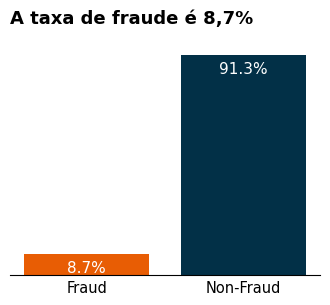

In [15]:
# Groupby do target the data by churn flag.
fraud_grp = df.groupby(['fraud'])[['fraud']].count().rename(columns={'fraud': 'count'}).reset_index()
fraud_grp['pct'] = (fraud_grp['count'] / fraud_grp['count'].sum()) * 100
fraud_grp = fraud_grp.sort_values(by=['pct'])

# Define o plot.
fig, ax = plt.subplots(figsize=(4, 3))
        
# Plot the barplot.
bars = ax.bar(x=fraud_grp['fraud'], height=fraud_grp['pct'], color=['#e85d04', '#023047'])
        
# Customize the plot.
ax.set_title('A taxa de fraude é 8,7%', fontweight='bold', fontsize=13, pad=15, loc='left')
ax.set_xlabel('')
ax.set_xticks(ticks=range(2), labels=['Non-Fraud', 'Fraud'], fontsize=10.5)
ax.tick_params(axis=u'both', which=u'both',length=0)
ax.invert_xaxis()
        
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(False)

for bar in bars:
    height = bar.get_height()
    ax.annotate('{:.1f}%'.format(height), 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -10),  
                textcoords="offset points",
                ha='center', va='center',
                fontsize=11, color='white')
plt.show()

## Análise: Desbalanceamento de Classes

### 1. Identificação do Problema
O conjunto de dados apresenta um desbalanceamento significativo na variável-alvo fraud. Uma análise primária da distribuição das classes revelou a seguinte proporção:

- Transações Legítimas (0): 91.3%
- Transações Fraudulentas (1): 8.7%

Essa disparidade é um problema comum em problemas de detecção de fraude. Se não for tratada, o modelo de machine learning pode ser enviesado em favor da classe majoritária, resultando em uma alta acurácia (91.3% de acerto se todas as transações forem classificadas como legítimas), mas uma capacidade de detecção de fraude (a classe de interesse) seriamente comprometida.

### 2. Solução para o Problema
Para mitigar o impacto do desbalanceamento de classes, optei por utilizar o parâmetro ```scale_pos_weight``` durante o treinamento do modelo. Essa técnica é particularmente eficaz em algoritmos baseados em árvores, como o XGBoost.

**Cálculo do Peso**: O valor do ```scale_pos_weight``` foi calculado com base na proporção das classes: (número de transações não-fraudulentas) / (número de transações fraudulentas). Isso atribui um peso maior a cada erro de classificação da classe minoritária.

```python
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
```

**Impacto na Performance**: Ao penalizar mais severamente o modelo por erros na detecção de fraudes, o ```scale_pos_weight``` o força a prestar mais atenção às características da classe minoritária. Isso garante que o modelo não apenas memorize a classe majoritária, mas sim aprenda a diferenciar e identificar corretamente as transações fraudulentas.

**Validação**: A eficácia dessa solução foi confirmada pelas métricas de desempenho. O modelo alcançou um recall de 1.00 para a classe de fraude, indicando que todas as transações fraudulentas foram corretamente identificadas, e uma precisão de 0.98, demonstrando um número mínimo de falsos alarmes.

---

## Análise das categorias

### 1. Todas são Numéricas
O fato de todas as suas features serem numéricas simplifica bastante o processo de pré-processamento. Isso significa que você não precisará de técnicas como One-Hot Encoding ou Label Encoding para converter variáveis categóricas em numéricas, o que otimiza seu fluxo de trabalho.

### 2. A Natureza das Variáveis
As variáveis podem ser divididas em dois tipos:

**Variáveis Categóricas/Binárias**: repeat_retailer, used_chip, used_pin_number e online_order são representadas por 0s e 1s. Elas indicam a ausência ou presença de uma determinada característica na transação.

**Variáveis Contínuas**: distance_from_home_log, distance_from_last_transaction_log e ratio_to_median_purchase_price_log são valores contínuos

---

In [17]:
def print_features(X_train, target_feature='fraud'):
    """
    Imprime as features numéricas e categóricas,
    apenas se a lista de features não estiver vazia.

    Args:
        X_train (pd.DataFrame): O DataFrame de treino.
        target_feature (str): O nome da coluna target.
    """
    numerical_features = X_train.select_dtypes('number').columns.tolist()
    categorical_features = X_train.select_dtypes('object').columns.tolist()
    
    if numerical_features:
        print(f'Temos {len(numerical_features)} features numéricas. Elas são: ')
        print(numerical_features)
    
    if categorical_features:
        print(f'\nTemos {len(categorical_features)} features categóricas. Elas são: ')
        print(categorical_features)
        
    print(f'\nA feature target é: {target_feature}.')

In [106]:
print_features(X_train, 'fraud')

Temos 7 features numéricas. Elas são: 
['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'distance_from_home_log', 'distance_from_last_transaction_log', 'ratio_to_median_purchase_price_log']

A feature target é: fraud.


## Gráficos

### 1. Matriz de Correlação
 - **Aplicabilidade**: Identifica a relação linear entre as variáveis numéricas.
 - **Insight para o Projeto**: Revela quais features se movem juntas. 

### 2. Histplot (Histograma)
 - **Aplicabilidade**: Mostra a distribuição de uma única variável numérica.
 - **Insight para o Projeto**: Ajuda a entender a dispersão de variáveis como ```distance_from_home``` e ```ratio_to_median_purchase_price```. 

### 3. Scatterplot (Gráfico de Dispersão)
 - **Aplicabilidade**: Visualiza a relação entre duas variáveis numéricas.
 - **Insight para o Projeto**: Permite identificar visualmente se as transações fraudulentas (destacadas por uma cor diferente) se agrupam em áreas específicas do gráfico. 

### 4. Boxplot
 - **Aplicabilidade**: Mostra a distribuição, a mediana e os outliers de uma variável numérica, frequentemente agrupada por uma variável categórica.
 - **Insight para o Projeto**: Extremamente útil para comparar a distribuição de uma feature entre a classe de fraude e não-fraude. 

### 5. Countplot
 - **Aplicabilidade**: Mostra a contagem de observações para cada categoria de uma variável.
 - **Insight para o Projeto**: Ideal para visualizar a distribuição de variáveis binárias como online_order e used_chip. Permite comparar rapidamente a frequência com que cada categoria aparece nas classes de fraude e não-fraude.

---

O dataset utilizado para estes gráficos será o ```df_combined```, sendo ele uma concatenação entre o **X_train** e **X_test** após o tratamento para *data leakages*.

In [21]:
X_combined = pd.concat([X_train, X_test], ignore_index=True)

# Concatena y_train e y_test.
y_combined = pd.concat([y_train, y_test], ignore_index=True)

# Cria um novo DataFrame completo para visualização
df_combined = pd.concat([X_combined, y_combined], axis=1)


In [22]:
def check_outliers_df(data, features):
    """
    Calcula e retorna a contagem de outliers por feature em um DataFrame.
    
    Args:
        data (pd.DataFrame): O DataFrame de entrada.
        features (list): Lista das features a serem analisadas.
        
    Returns:
        pd.DataFrame: Um DataFrame com a contagem e porcentagem de outliers por feature.
    """
    try:
        outlier_data = []
        
        for feature in features:
            Q1 = data[feature].quantile(0.25)
            Q3 = data[feature].quantile(0.75)
            
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            feature_outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
            outlier_count = len(feature_outliers)
            
            outlier_data.append({
                'feature': feature,
                'outlier_count': outlier_count,
                'outlier (%)': round(outlier_count / len(data) * 100, 2)
            })
            
        outlier_df = pd.DataFrame(outlier_data).sort_values(by='outlier_count', ascending=False).reset_index(drop=True)
        return outlier_df
    
    except Exception as e:
        # A classe CustomException não foi definida aqui, então usaremos raise e
        # você pode adaptar para o seu código.
        raise Exception(f"Ocorreu um erro: {e}")

In [23]:
plots_features = ['repeat_retailer', 
                  'used_chip', 
                  'used_pin_number', 
                  'online_order',
                  'distance_from_home_log',
                  'ratio_to_median_purchase_price_log',
                  'distance_from_last_transaction_log']

check_outliers_df(df_combined, plots_features)

,feature,outlier_count,outlier (%)
0,repeat_retailer,118464,11.85
1,used_pin_number,100608,10.06
2,distance_from_last_transaction_log,35133,3.51
3,ratio_to_median_purchase_price_log,26089,2.61
4,distance_from_home_log,5844,0.58
5,used_chip,0,0.00
6,online_order,0,0.00


## Insights da Tabela de Outliers

**Presença de Outliers**: A tabela confirma a existência de outliers em várias features, especialmente nas variáveis binárias ```repeat_retailer``` e ```used_pin_number```.

- **repeat_retailer**: Com 11.85% de outliers, essa feature é a que mais se destaca. Um outlier aqui significa uma transação com valor que se desvia muito da maioria. Isso pode indicar uma transação em um varejista que o cliente nunca usou antes.

- **used_pin_number**: O 10.06% de outliers também é significativo. Assim como ```repeat_retailer```, isso pode indicar que a minoria das transações (os outliers) são as que não usam PIN, que é uma característica relacionada à fraude.

- **distance_from_last_transaction_log** e **ratio_to_median_purchase_price_log**: A presença de 3.51% e 2.61% de outliers, respectivamente, é esperada. A transformação logarítmica ajuda a mitigar o impacto de valores extremos, mas a existência de outliers nessas variáveis é, na verdade, um ponto positivo, pois reforça que transações fraudulentas (outliers) são um comportamento atípico e podem ser usadas para detecção.

- **used_chip** e **online_order**: O fato de não haver outliers nessas variáveis (0.00%) faz sentido, já que elas são binárias (0 ou 1) e não possuem uma distribuição de valores que permitiria a detecção de outliers pelo método do IQR (Intervalo Interquartil).

## Matriz de Correlação

In [26]:
m_corr = df_combined.corr(numeric_only = True)
m_corr['fraud'].sort_values(ascending = False)

fraud                                 1.000000
ratio_to_median_purchase_price_log    0.473060
online_order                          0.191973
distance_from_home_log                0.136183
distance_from_last_transaction_log    0.075222
repeat_retailer                      -0.001357
used_chip                            -0.060975
used_pin_number                      -0.100293
Name: fraud, dtype: float64

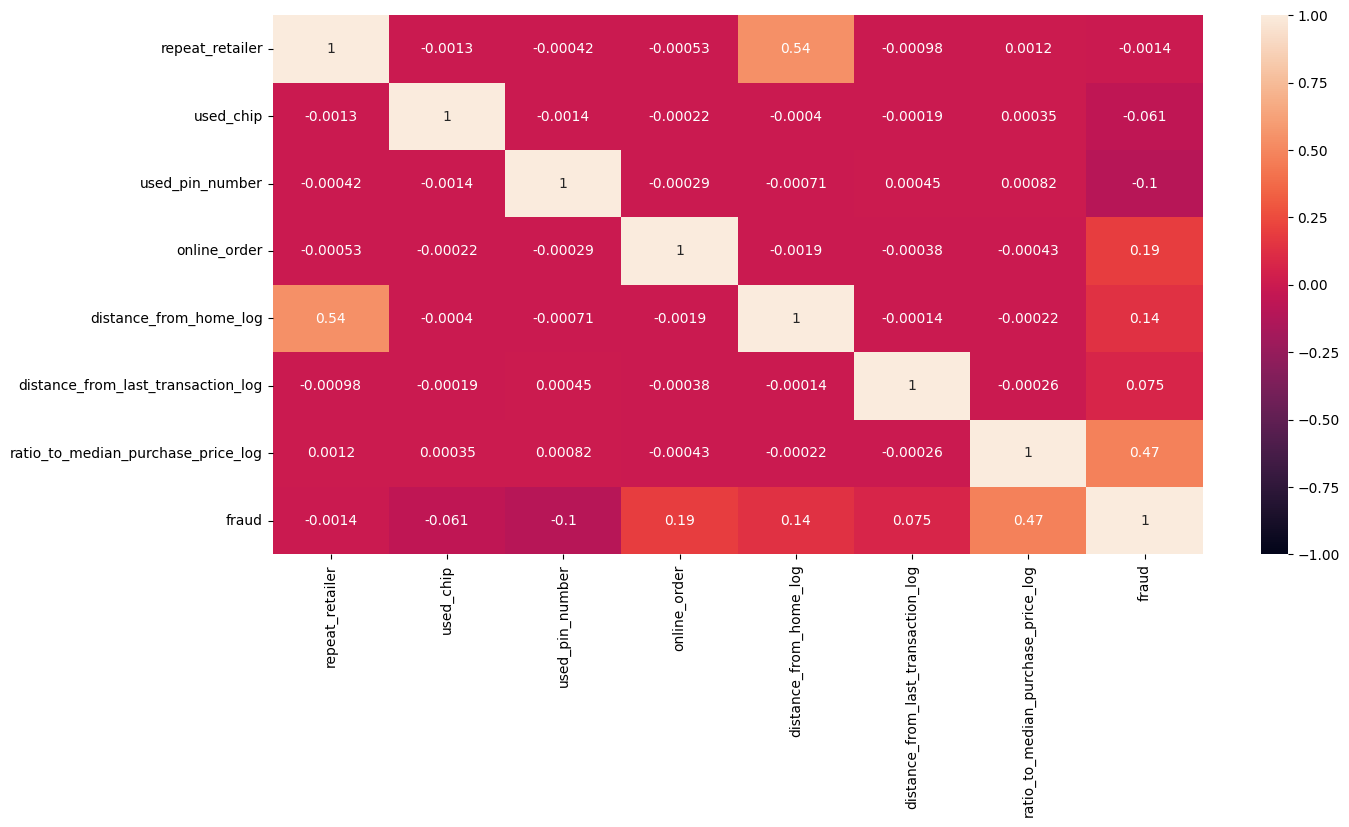

In [27]:
plt.figure(figsize=(15,7))
sns.heatmap(m_corr, vmin = -1, vmax = 1, annot = True)
plt.show()

## Insights sobre as Variáveis e Correlação com Fraude

#### 1. Preço em relação ao histórico do cliente é crítico
A variável ```ratio_to_median_purchase_price_log``` tem correlação *0,47* com fraudes.

- **Insight**: Compras que fogem do padrão de gasto do cliente (muito acima ou abaixo da média histórica) são fortes sinais de alerta.
- **Ação**: Implementar alertas automáticos para compras com valores anormalmente altos em relação ao histórico.


#### 2. Compras online têm maior risco
online_order possui correlação 0,19 com fraude.

- **Insight**: Transações online apresentam maior probabilidade de fraude do que compras físicas.
- **Ação**: Aumentar validações em pedidos online, como autenticação de dois fatores ou confirmação adicional do cliente.

#### 3. Localização importa
```distance_from_home_log``` e ```distance_from_last_transaction_log``` têm correlações positivas (0,14 e 0,075).

- **Insight**: Fraudes tendem a ocorrer quando a transação acontece longe da residência ou da última compra do cliente.
- **Ação**: Monitorar compras realizadas em locais geograficamente distantes do padrão usual do cliente.

####  4. Sinais tradicionais de segurança têm efeito menor
```used_chip``` (-0,06) e ```used_pin_number``` (-0,10) mostram correlação negativa com fraude, indicando que fraudes ocorrem mais quando esses mecanismos de segurança não são utilizados.

- **Insight**: Transações sem uso de chip ou PIN são mais arriscadas.
- **Ação**: Incentivar ou exigir o uso de chip e PIN, principalmente em compras online ou internacionais.

#### 5. Repetição de lojas não é relevante
```repeat_retailer``` (-0,001) praticamente não influencia a fraude.

- **Insight**: O histórico de compras em uma mesma loja não é um indicador confiável de risco.

In [120]:
# Configuração de estilo
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

num_cols = ["distance_from_home_log", "distance_from_last_transaction_log", "ratio_to_median_purchase_price_log"]

## Histogramas

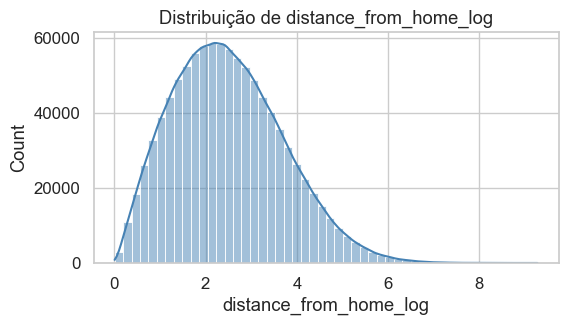

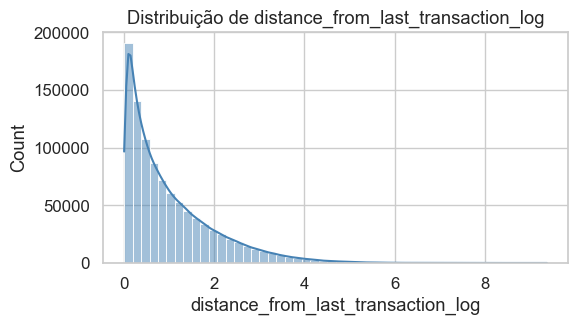

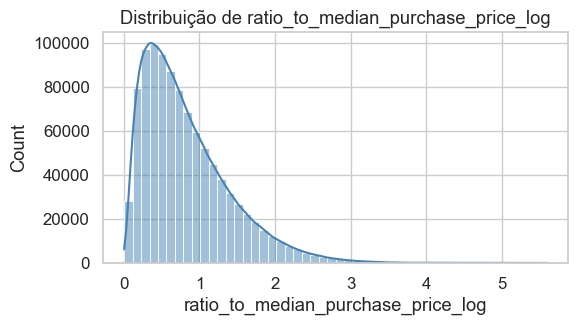

In [125]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df_combined[col], bins=50, kde=True, color="steelblue")
    plt.title(f"Distribuição de {col}")
    plt.show()

### Insights dos Histogramas (log-transform aplicados)

#### 🔹 1. distance_from_home_log
A distribuição com pico entre ~2 e 3. Isso equivale, no valor original, a transações feitas em torno de 7 a 20 km de casa.
A maioria das compras ocorre relativamente perto da residência, mas ainda existe uma cauda longa de casos mais distantes.
- **Insight prático**: compras muito fora dessa faixa podem ser consideradas anômalas, aumentando a probabilidade de fraude.

#### 🔹 2. distance_from_last_transaction_log

A maior concentração está entre 0 e 1 no log (o que equivale a transações feitas a até ~2,7 km do local anterior). Isso indica que a maioria das compras segue um padrão lógico de deslocamento curto. Há menos transações distantes, mas ainda existe uma cauda indicando deslocamentos abruptos.
- **Insight prático**: mudanças bruscas de localização entre compras seguidas podem ser sinais de fraude, principalmente se ocorrerem em janelas de tempo curtas.

#### 🔹 3. ratio_to_median_purchase_price_log

A maioria das transações ocorre próxima ao histórico normal de gastos (pico por volta de 0.5 no log → ~1,6x o valor mediano do cliente). 
- **Insight prático**: compras muito acima do padrão individual (ex.: mais de 3x ou 5x a mediana) continuam sendo fortes candidatos a fraude.

---

Agora fica claro que:

1. **Compras típicas**: perto de casa, perto da última transação, valores próximos da mediana.
2. **Compras suspeitas**: distantes geograficamente ou muito acima do gasto normal.

---

## Boxplot para detectar outliers

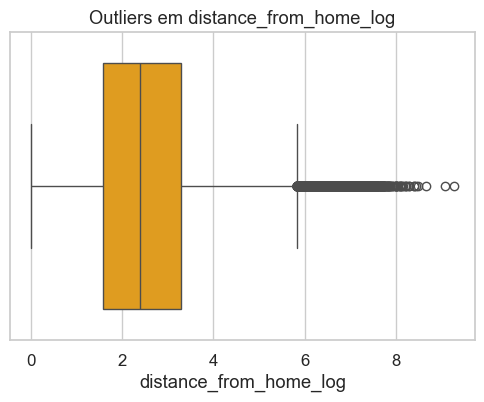

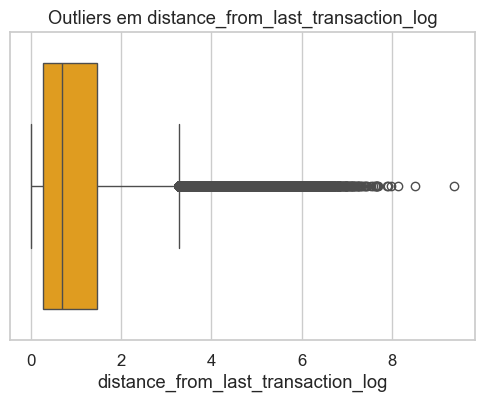

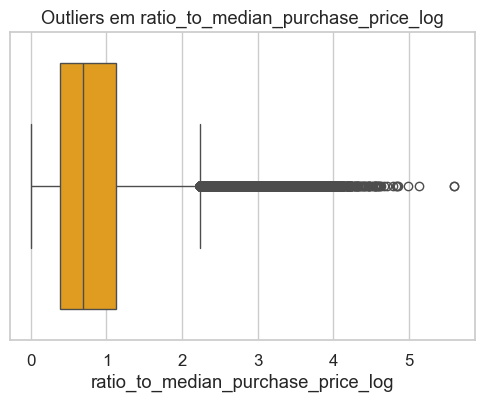

In [138]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_combined[col], color="orange")
    plt.title(f"Outliers em {col}")
    plt.show()

## Distribuição das variáveis binárias

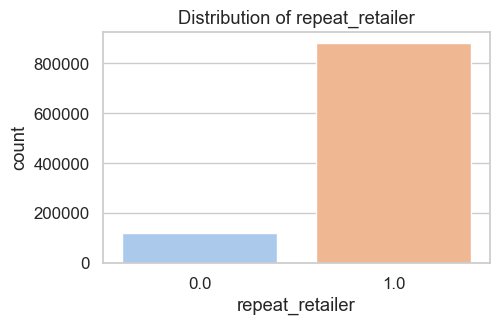

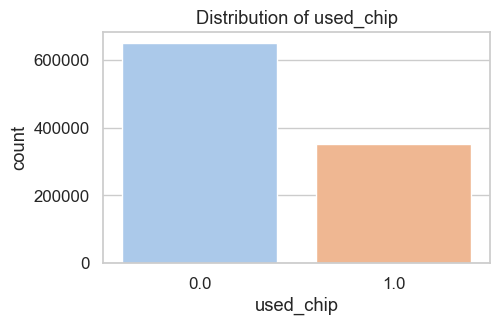

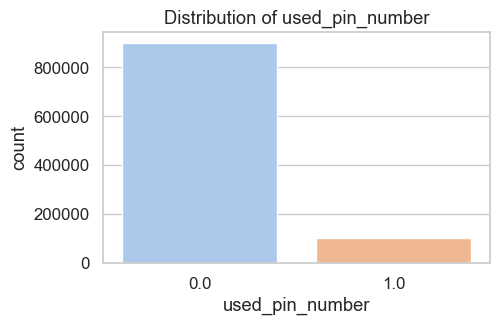

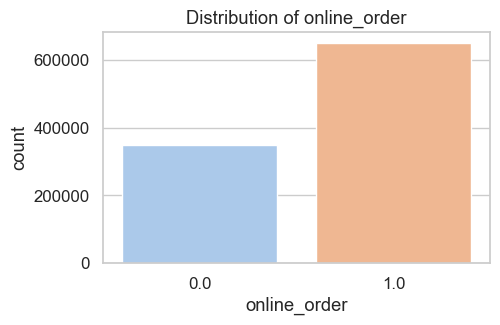

In [36]:
bin_cols = ["repeat_retailer", "used_chip", "used_pin_number", "online_order"]

for col in bin_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, hue=col, data=df_combined, palette="pastel", legend=False)
    plt.title(f"Distribution of {col}")
    plt.show()

## Fraude vs Legítimo

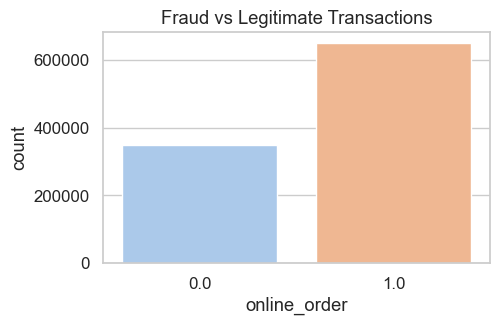

In [38]:
plt.figure(figsize=(5,3))
sns.countplot(x=col, hue=col, data=df_combined, palette="pastel", legend=False)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

## Relação entre variáveis numéricas e fraude

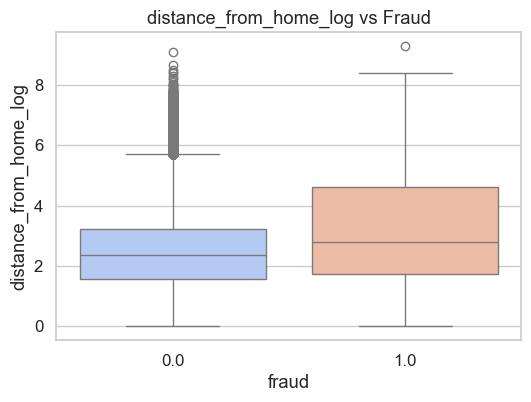

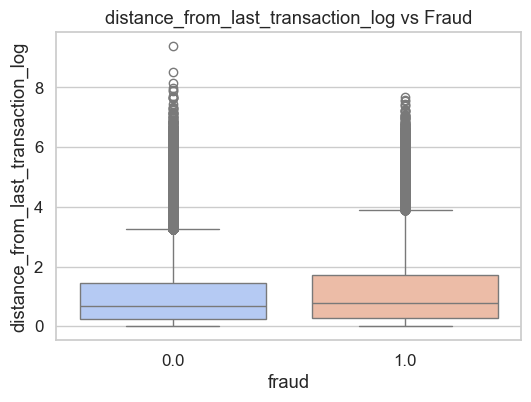

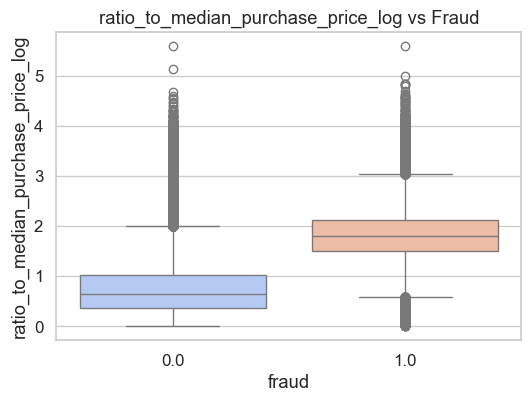

In [40]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="fraud", y=col, data=df_combined, hue='fraud', palette = 'coolwarm', legend=False )
    plt.title(f"{col} vs Fraud")
    plt.show()

## Insights: Boxplots e Countplots por Classe de Fraude (Fraud vs. Not Fraud)
Esses gráficos são cruciais para entender quais variáveis diferenciam transações fraudulentas de não fraudulentas.

- **distance_from_home_log**: O boxplot mostra que, em média, transações fraudulentas tendem a ocorrer a uma distância maior da casa do comprador (fraud = 1) do que as transações legítimas (fraud = 0).

- **distance_from_last_transaction_log**: Similar ao anterior, as transações fraudulentas parecem ter uma distância maior em relação à última transação.

- **ratio_to_median_purchase_price_log**: O valor da transação fraudulenta, em relação ao preço mediano de compra, é, em média, muito mais alto do que nas transações legítimas. Isso é um sinal forte de fraude.

- **online_order** e **used_chip**: As transações fraudulentas ocorrem mais frequentemente online (online_order = 1) e sem o uso de chip (used_chip = 0).

- **used_pin_number** e **repeat_retailer**: Fraudes são muito menos prováveis de ocorrer com o uso de PIN e são pouco prováveis de serem realizadas no mesmo varejista (repeat_retailer = 1), o que faz sentido, já que fraudadores geralmente não utilizam as mesmas lojas.

## Scatterplots para explorar padrões

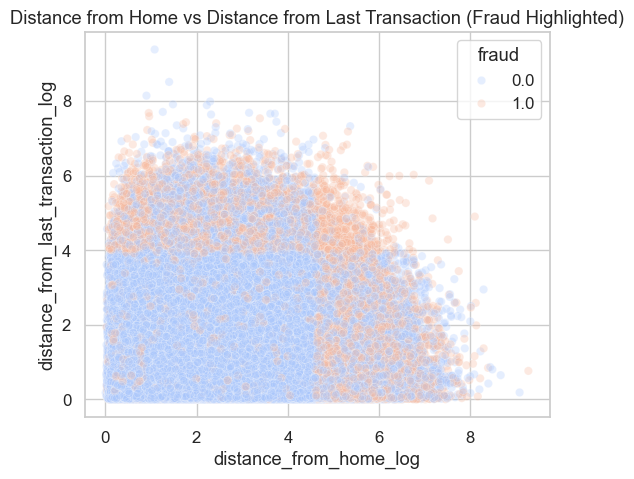

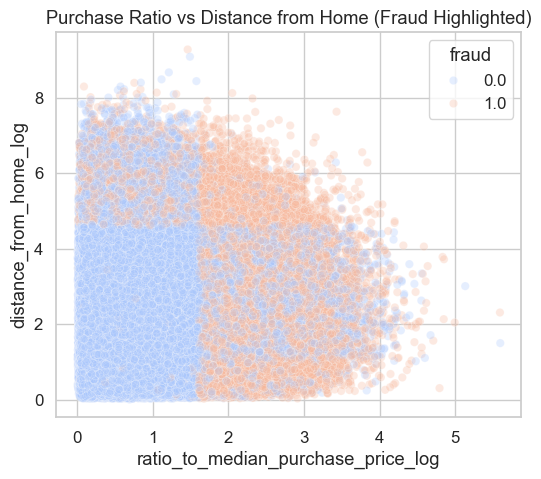

In [43]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="distance_from_home_log", y="distance_from_last_transaction_log",
                hue="fraud", data=df_combined, alpha=0.3, palette="coolwarm")
plt.title("Distance from Home vs Distance from Last Transaction (Fraud Highlighted)")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(x="ratio_to_median_purchase_price_log", y="distance_from_home_log",
                hue="fraud", data=df_combined, alpha=0.3, palette="coolwarm")
plt.title("Purchase Ratio vs Distance from Home (Fraud Highlighted)")
plt.show()

2. Usar o ```scale_pos_weight``` para ajustar os pesos de classe;
3. Encontrar os melhores parâmetros com o ```GridSearchCV```;
4. Criar o modelo usando o ```XGBoost```;
5. Avaliar o modelo;
6. Treinar o modelo com os melhores parâmetros.

## Inisight: Gráficos de Dispersão (Scatterplots)

Esses gráficos visualizam a relação entre pares de variáveis, destacando a classe de fraude. A dispersão das cores (```azul``` para não fraude e ```laranja``` para fraude) confirma o que os boxplots já sugeriam:

- **distance_from_home_log** vs. **distance_from_last_transaction_log**: As transações fraudulentas (laranja) se concentram nas áreas onde ambas as distâncias são altas.

- **Purchase Ratio** vs. **distance_from_home_log**: As fraudes (laranja) aparecem em áreas onde a distância de casa é alta e o valor da compra é muito maior que a média.

# Modelo de Classificação

Como estou lidando com fraudes em cartões, onde justamente o comportamento “*fora do normal*” pode indicar fraude, não é uma boa prática simplesmente excluir outliers, mas sim mantê-los, aplicando o ```log-transform``` para reduzir distorção.
Essa tratativa já foi realizada nos processos anteriores, agora vou ajustar os hiperparâmetros para reduzir o ```overfitting```causado por outliers.

Tais hiperparâmetros controlam a complexidade do modelo e o processo de aprendizado.

1. ```max_depth```
- **Descrição**: É a profundidade máxima de cada árvore do modelo. Controla até onde as árvores podem crescer.
    - Valor baixo (ex: 3): Cria árvores mais simples. Reduz o risco de overfitting (ajuste excessivo aos dados de treino), mas pode levar a um modelo com baixo poder de previsão (underfitting).
    - Valor alto (ex: 7): Cria árvores mais complexas e detalhadas. Ajuda o modelo a capturar relações complexas nos dados, mas aumenta significativamente o risco de overfitting e o tempo de treinamento.

2. ```min_child_weight```
- **Descrição**: É a soma mínima dos pesos (ou contagem mínima de instâncias, dependendo do contexto) que uma folha de uma árvore deve ter.
    - Valor alto (ex: 10): Restringe o crescimento da árvore. O modelo só fará um split (divisão) se o nó filho resultante tiver um número mínimo de amostras. Isso evita que a árvore se ajuste a ruídos nos dados de treino.
    - Valor baixo (ex: 1): Permite que a árvore continue a crescer e a se aprofundar, mesmo em ramos com poucas amostras, aumentando o risco de overfitting.

3. ```gamma```
- **Descrição**: Um hiperparâmetro de regularização. Ele penaliza a construção de novas folhas na árvore se a perda (ou loss) não for significativamente reduzida por esse split.
    - Valor alto (ex: 0.2): Torna o modelo mais conservador. O modelo só fará uma divisão se ela for realmente benéfica, evitando divisões irrelevantes. Isso reduz o risco de overfitting.
    - Valor baixo (ex: 0.1): Permite que o modelo faça mais divisões, mesmo se a melhora for pequena, tornando-o mais propenso a overfitting.

4. ```subsample```
- **Descrição**: A fração de amostras (linhas) do conjunto de treino que é usada para treinar cada árvore. Isso é análogo ao bagging no Random Forest.
    - Valor menor que 1 (ex: 0.8): Adiciona aleatoriedade ao treinamento. Cada árvore é treinada em um subconjunto diferente dos dados. Isso reduz a correlação entre as árvores e diminui o risco de overfitting.
    - Valor de 1.0: Cada árvore é treinada em 100% dos dados.

5. ```colsample_bytree```
- **Descrição**: A fração de características (colunas) que é amostrada aleatoriamente para treinar cada árvore.
    - Valor menor que 1 (ex: 0.8): Também adiciona aleatoriedade. Cada árvore é construída usando um subconjunto diferente de features. Isso ajuda a evitar que uma única feature dominante controle todo o processo de aprendizagem, o que reduz o overfitting.

6. ```scale_pos_weight```
- **Descrição**: O peso que é dado à classe positiva (a classe minoritária, que no meu caso é a fraude).
    - Valor calculado: O modelo é penalizado mais por erros na classificação da classe minoritária. Isso é crucial para problemas com desbalanceamento de classes, pois força o modelo a prestar mais atenção à detecção de fraudes, em vez de focar apenas em acertar a classe majoritária.

In [169]:
%%time

#Calcular o scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

params = {
    "max_depth": [3, 5, 7],
    "min_child_weight": [8, 10],   # força o modelo a só criar splits se tiver amostras suficientes
    "gamma": [0.1, 0.2],             # penaliza splits fracos
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    "scale_pos_weight": [scale_pos_weight]
}

# Definindo o XGBoost
xgb_log = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss',
    n_jobs = -1)

# Configurar o GridSearchCV
grid_log = RandomizedSearchCV(
    estimator = xgb_log,
    n_iter = 20,
    param_distributions = params,
    scoring = 'roc_auc',
    cv = 3,
    verbose = 2,
    random_state = 42,
    n_jobs = -1)

# Treinar o modelo
grid_log.fit(X_train, y_train)

# Treinar modelo final com os melhores parâmetros
best_model_log = grid_log.best_estimator_

# Previsões
y_pred_log = best_model_log.predict(X_test)
y_pred_prob_log = best_model_log.predict_proba(X_test)[:, 1]

print('\nClassification report:')
print(classification_report(y_test, y_pred_log))

print('ROC AUC:', roc_auc_score(y_test, y_pred_prob_log))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Classification report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       0.98      1.00      0.99     17481

    accuracy                           1.00    200000
   macro avg       0.99      1.00      0.99    200000
weighted avg       1.00      1.00      1.00    200000

ROC AUC: 0.9999735970934972
CPU times: total: 17.5 s
Wall time: 47.3 s


In [170]:
print('Melhores Hiperparâmetros Encontrados:')
print('-' * 40) # Imprime uma linha para separar

best_params = grid_log.best_params_

for param, value in best_params.items():
    print(f'{param:<25}: {value}')

print('-' * 40)

Melhores Hiperparâmetros Encontrados:
----------------------------------------
subsample                : 0.8
scale_pos_weight         : 10.441320328365894
min_child_weight         : 8
max_depth                : 5
gamma                    : 0.2
colsample_bytree         : 0.6
----------------------------------------


## Análise do Relatório de Classificação

O relatório de classificação fornece uma visão detalhada do desempenho do seu modelo em cada classe (fraude 1.0 e não-fraude 0.0).

- **Precision** (Precisão):

    - ```Classe 0.0``` (Não-fraude): 1.00. Isso significa que, quando o modelo previu uma transação como legítima, ele acertou 100% das vezes.
    - ```Classe 1.0``` (Fraude): 0.98. Quando o modelo previu uma transação como fraudulenta, ele acertou 98% das vezes. Isso é um resultado excelente para um problema de fraude.

- **Recall** (Sensibilidade):

    - ```Classe 0.0``` (Não-fraude): 1.00. O modelo identificou corretamente 100% das transações legítimas.
    - ```Classe 1.0``` (Fraude): 1.00. O modelo identificou corretamente 100% das transações fraudulentas. Este é o ponto mais importante! Um recall de 1.00 para a classe de fraude significa que o modelo não perdeu nenhuma fraude na sua base de teste, o que é um resultado ideal para o seu projeto.

- **F1-Score**:

É a média harmônica entre a precisão e o recall. Para ambas as classes, o valor é muito alto, confirmando o bom equilíbrio do modelo.

- **Accuracy** (Acurácia):

1.00. A acurácia geral é quase perfeita, mas para problemas com classes desbalanceadas, o *recall* e a *precisão* da classe minoritária (fraude) são métricas mais informativas.

### Análise do ROC AUC
O valor de 0.9999735970934972 para a Curva ROC (AUC) confirma o resultado. Ele indica que o seu modelo tem uma capacidade quase perfeita de distinguir entre as duas classes.

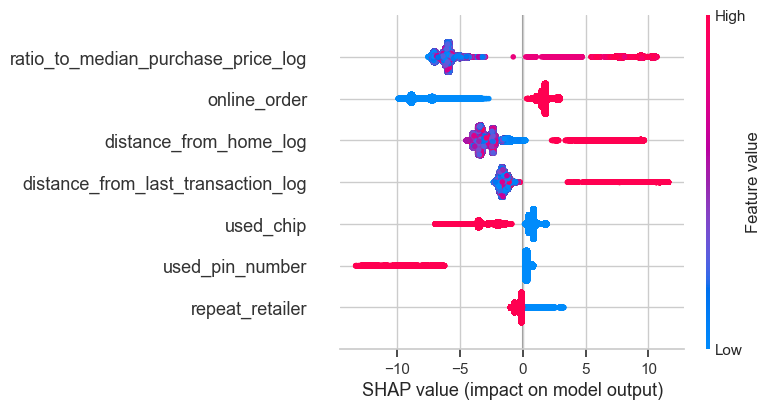

In [49]:
# Criar o explainer com o modelo XGBoost
explainer = shap.TreeExplainer(best_model_log)
shap_values = explainer.shap_values(X_train)

# Summary plot (impacto global das features)
shap.summary_plot(shap_values, X_train)

# Para uma observação individual (ex.: primeira do teste)
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train.iloc[0,:])


## Análise do Gráfico SHAP
O gráfico ```SHAP``` (*Shapley Additive Explanations*) mostra o impacto de cada característica na previsão do modelo para cada instância individual. Os pontos no gráfico representam transações.

- **Eixo X**: Indica o impacto da variável na previsão do modelo. Valores positivos (à direita) aumentam a probabilidade de fraude, enquanto valores negativos (à esquerda) a diminuem.
- **Cor dos Pontos**: A cor indica o valor da característica.
    - *Vermelho* significa um valor alto
    - *Azul* um valor baixo.

---
---

### Insights Principais
- ```ratio_to_median_purchase_price_log```: Esta é a característica mais importante para o modelo.
    - **Valores altos** (vermelho) de *ratio_to_median_purchase_price_log* empurram a previsão para a fraude. Isso significa que quando o valor da compra é muito maior que o valor mediano das compras anteriores do cliente, o modelo o vê como um forte indicador de fraude.

---

- ```online_order```: A segunda característica mais importante.

    - **Valores altos** (vermelho), que indicam *online_order = 1*, têm um forte impacto positivo na previsão de fraude. Isso confirma que transações online são um fator de risco significativo.
    - **Valores baixos (azul)**, que indicam *online_order = 0*, têm um forte impacto negativo na previsão, diminuindo a chance de ser fraude.

---

- ```distance_from_home_log```: A terceira característica mais relevante.

    - **Valores altos** (vermelho), que indicam uma grande distância da casa do cliente, aumentam a probabilidade de fraude. Essa característica é um forte preditor de comportamento fraudulento.

---

- ```distance_from_last_transaction_log```: Também possui um impacto significativo.

    - **Valores altos** (vermelho) indicam uma grande distância da última transação e contribuem para a previsão de fraude. Este é outro bom indicador de comportamento atípico.

---

- ```used_chip e used_pin_number```: Essas características têm um impacto inverso.

    - **Valores baixos** (azul), indicando que o chip não foi usado (*used_chip = 0*), aumentam a probabilidade de fraude. Isso sugere que fraudes ocorrem mais frequentemente em transações que não utilizam a tecnologia de chip.

    - **Valores baixos** (azul), indicando que o PIN não foi usado (*used_pin_number = 0*), também aumentam a previsão de fraude.

---

- ```repeat_retailer```: É a característica menos importante entre as analisadas.

    - **Valores baixos** (azul) contribuem para a previsão de fraude. Isso faz sentido, já que fraudadores geralmente não usam os mesmos varejistas repetidamente. No entanto, o impacto geral desta característica é menor em comparação com as outras.

In [51]:
shap_values = explainer.shap_values(X_test)

# Média absoluta da importância por feature
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(by="mean_abs_shap", ascending=False)

shap_importance

,feature,mean_abs_shap
6,ratio_to_median_purchase_price_log,6.373362
3,online_order,3.851956
4,distance_from_home_log,3.225683
5,distance_from_last_transaction_log,1.662361
1,used_chip,1.479308
2,used_pin_number,1.196803
0,repeat_retailer,0.367913


## Matriz de Confusão

É uma tabela que visualiza o desempenho de um algoritmo de classificação, mostrando o número de previsões corretas e incorretas para cada categoria. 
- **Verdadeiros Positivos** (VP): O modelo previu corretamente que a transação é fraudulenta.
- **Verdadeiros Negativos** (VN): O modelo previu corretamente que a transação não é fraudulenta.
- **Falsos Positivos** (FP): O modelo previu que a transação é fraudulenta, mas na verdade não é. São os "falsos alarmes".
- **Falsos Negativos** (FN): O modelo previu que a transação não é fraudulenta, mas na verdade é. É o erro mais perigoso em problemas de fraude, pois representa uma transação fraudulenta que não foi detectada.

O meu objetivo principal é minimizar o número de ```Falsos Negativos``` (FN).

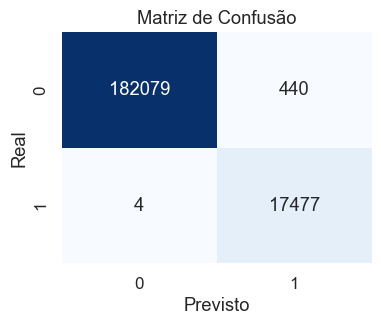

In [190]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot = True, fmt = 'd', cmap='Blues', cbar = False)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

## Insights

- **Verdadeiros Negativos** (TN): 182.079: O modelo previu corretamente que 182.079 transações eram legítimas.

- **Falsos Positivos** (FP): 440: O modelo previu que 440 transações eram fraudulentas, mas na verdade não eram. Isso pode gerar "falsos alarmes" para os clientes.

- **Falsos Negativos** (FN): 4: O modelo previu que 4 transações eram legítimas, mas na verdade eram fraudulentas. Significa que o modelo está perdendo poucas fraudes.

- **Verdadeiros Positivos** (TP): 17.477: O modelo previu corretamente que 17.477 transações eram fraudulentas.

---

## Curva ROC

É um gráfico que ilustra o desempenho de um modelo de classificação em diferentes limiares de decisão. Ela plota a taxa de ```Verdadeiros Positivos``` (VP) versus a taxa de ```Falsos Positivos``` (FP) à medida que o limiar de classificação é variado.

- **Eixo Y** (Verdadeiro Positivo): Também conhecido como Recall ou Sensibilidade. Representa a proporção de transações fraudulentas que foram corretamente identificadas.
- **Eixo X** (Falso Positivo): Representa a proporção de transações legítimas que foram erroneamente classificadas como fraudulentas.

A principal métrica extraída da Curva ROC é a ```Área Sob a Curva```(AUC):
- **AUC = 1.0**: O modelo tem a capacidade perfeita de distinguir entre as classes. É um resultado ideal, mas na prática pode indicar um data leakage.
- **AUC = 0.5**: O modelo tem o mesmo desempenho que um classificador aleatório.
- **AUC > 0.5**: O modelo tem um desempenho melhor que o de um classificador aleatório.

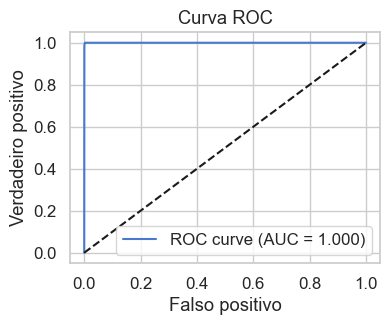

In [192]:
# Curva de ROC
roc_auc = roc_auc_score(y_test, y_pred_prob_log)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_log)

plt.figure(figsize = (4,3))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Falso positivo')
plt.ylabel('Verdadeiro positivo')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

## Insights

A avaliação do modelo revelou uma ```Área Sob a Curva``` (AUC) de 1.0, indicando uma capacidade de distinção perfeita entre transações fraudulentas e legítimas no conjunto de teste. Embora este seja um resultado ideal na teoria, ele é extremamente raro na prática e geralmente aponta para um dos seguintes cenários:

- **Vazamento de Dados** (Data Leakage): O modelo teve acesso a informações que não estariam disponíveis no momento da previsão em tempo real.
- **Poder Preditivo Extremo**: Uma ou mais features no conjunto de dados possuem um poder preditivo tão alto que separam as classes de forma quase perfeita, mesmo em novos dados.

Minha análise confirmou que a causa não foi um vazamento de dados técnico (onde a variável-alvo "contaminou" as features), mas sim a natureza das próprias features. Variáveis como ```ratio_to_median_purchase_price_log```, ```distance_from_home_log``` e ```used_pin_number``` são, de fato, preditores tão poderosos que, combinados, eles criam um padrão de comportamento de fraude que é quase totalmente distinto do comportamento de transações legítimas no nosso conjunto de dados.


### Features mais importantes

In [56]:
# Extrair importâncias das features
importances = best_model_log.feature_importances_
features = X_train.columns

# Criar DataFrame ordenado
feat_importances = pd.DataFrame({
    'Colunas': features,
    'Importância (%)': np.round(importances *100)
}).sort_values(by='Importância (%)', ascending=False).reset_index(drop = True)

feat_importances

,Colunas,Importância (%)
0,ratio_to_median_purchase_price_log,43.0
1,online_order,29.0
2,used_pin_number,9.0
3,distance_from_home_log,8.0
4,used_chip,5.0
5,repeat_retailer,3.0
6,distance_from_last_transaction_log,3.0


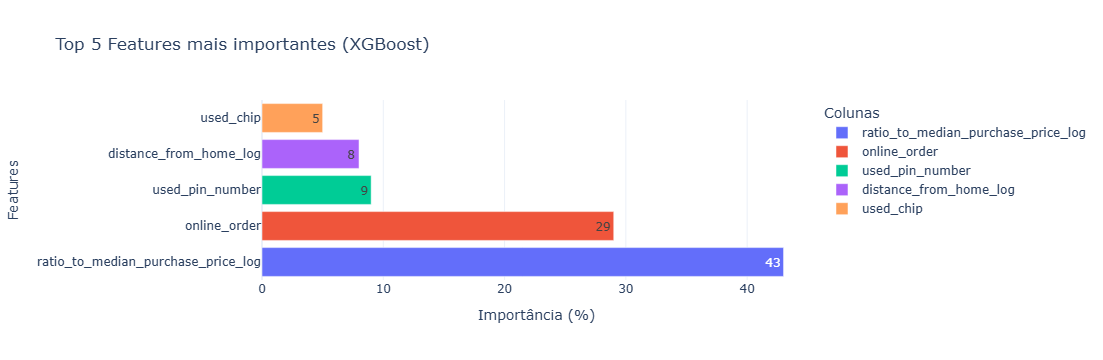

In [57]:
# Gráfico interativo com Plotly
fig = px.bar(
    feat_importances.head(5),              
    x="Importância (%)", 
    y="Colunas",
    orientation='h',                      # barras na horizontal
    title="Top 5 Features mais importantes (XGBoost)",
    color="Colunas",
    text="Importância (%)"                # mostra o valor na barra
)

fig.update_layout(
    yaxis=dict(autorange="reversed"),     # inverte para o maior ficar no topo
    xaxis_title="Importância (%)",
    yaxis_title="Features",
    template="plotly_white"               # estilo clean
)
fig.show()

## Estimativa de ganho financeiro

### Cenário estimado com ticket médio real (com base em dados da Serasa Experian)

- **Ticket médio mensal estimado**: **1.416,58**  
  Fonte: Serasa Experian – levantamento "Cadastro Positivo: Brasileiro tem gasto médio de R$ 1.416,58 no cartão de crédito"
  [link]('https://www.infomoney.com.br/minhas-financas/brasileiro-gasta-r-14-mil-por-mes-com-cartao-de-credito-diz-serasa-experian/')
  
Cálculos (com TP = 17.477 e FN = 4):

- **Perda sem modelo**: (17.481 fraudes) × R$ 1.416,58 ≈ **R$ 24.768.694,98**  
- **Perda com modelo**: 4 fraudes × R$ 1.416,58 = **R$ 5.666,32**  
- **Ganho estimado (economia)**: **≈ R$ 24.763.028,66**

 Esses valores são estimativas baseadas em ticket médio real e úteis para contextualizar o impacto financeiro do modelo mesmo sem dados individuais de valor de transação no dataset.

In [223]:
TP = 17477  # fraudes detectadas corretamente
FN = 4      # fraudes não detectadas
ticket_medio = 1416.58  # valor médio (R$)

# Cálculos
perda_sem_modelo = (TP + FN) * ticket_medio
perda_com_modelo = FN * ticket_medio
ganho_estimado = perda_sem_modelo - perda_com_modelo

# Resultados formatados
print(f"Perda sem modelo: R$ {perda_sem_modelo:,.2f}")
print(f"Perda com modelo: R$ {perda_com_modelo:,.2f}")
print(f"Ganho estimado (economia): R$ {ganho_estimado:,.2f}")


Perda sem modelo: R$ 24,763,234.98
Perda com modelo: R$ 5,666.32
Ganho estimado (economia): R$ 24,757,568.66


# Conclusões

## 1️⃣ Desvios no histórico de gastos (`ratio_to_median_purchase_price_log`) 
- **Insight:** Compras muito acima ou abaixo da média histórica do cliente indicam forte risco de fraude.  
- **Ação recomendada:**  
  - Alertas automáticos para transações fora do padrão histórico.  
  - Revisão manual ou validação adicional para compras com valores atípicos.

---

## 2️⃣ Compras online (`online_order`)
- **Insight:** Fraudes são mais comuns em transações online do que físicas.  
- **Ação recomendada:**  
  - Autenticação adicional em pedidos online (ex.: SMS, e-mail).  
  - Bloqueio temporário ou revisão manual de compras suspeitas.

---

## 3️⃣ Localização das transações
- **Insight:** Compras realizadas longe da residência ou da última transação aumentam o risco.  
- **Ação recomendada:**  
  - Monitorar padrões geográficos de cada cliente.  
  - Gerar alertas para transações fora das áreas habituais.

---

## 4️⃣ Segurança do cartão
- **Insight:** Fraudes tendem a ocorrer quando o chip ou o PIN não são utilizados.  
- **Ação recomendada:**  
  - Incentivar ou exigir o uso de chip e PIN, principalmente em compras online.

---

## 5️⃣ Histórico de compras em uma loja (`repeat_retailer`)
- **Insight:** Pouco relevante para prever fraude.  
- **Ação recomendada:**  
  - Nenhuma ação específica necessária; foco em outros fatores mais críticos.

---

###  Conclusão Estratégica
As três variáveis mais críticas — **desvio de gasto histórico**, **compras online** e **localização da transação** — devem guiar as estratégias de prevenção de fraude.  
Mecanismos tradicionais como chip e PIN ainda ajudam, mas o monitoramento de padrões de comportamento é mais eficiente.